<a href="https://colab.research.google.com/github/Montasir00/Ml_final_project/blob/tabby/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project**

Team members:
1. Pham Gia Khiem - 551026 (Vietnam)
2. Mohammed Hassan – 541140 (Bangladesh)
3. Fazlur Rahman - 541927 (Bangladesh)

# I. UNDERSTANDING THE DATASET

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from sklearn.preprocessing import PolynomialFeatures


In [ ]:
df = pd.read_csv('/content/final_project_dataset_complete.csv')
df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0
...,...,...,...,...,...,...,...,...,...,...,...
8995,0.101630,0.400250,NaN,-0.019412,-0.063150,0.077627,0.540975,-0.169030,Above Average,Region A,0
8996,1.167218,2.177774,-1.716067,1.994835,0.350043,-0.544915,0.089050,-0.944220,High,Region C,1
8997,1.588447,3.333945,-2.615488,3.476880,-0.933276,2.027658,0.239583,1.951491,High,Region C,1
8998,-0.684987,-1.599835,1.063341,-1.252109,-0.724001,2.228943,0.989794,1.936476,Low,Region B,0


In [ ]:
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   9000 non-null   float64
 1   feature_2   9000 non-null   float64
 2   feature_3   8600 non-null   float64
 3   feature_4   9000 non-null   float64
 4   feature_5   9000 non-null   float64
 5   feature_6   8500 non-null   float64
 6   feature_7   9000 non-null   float64
 7   feature_8   9000 non-null   float64
 8   category_1  9000 non-null   object 
 9   category_2  9000 non-null   object 
 10  target      9000 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 773.6+ KB


In [ ]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,8600.000000,9000.000000,9000.000000,8500.000000,9000.000000,9000.000000,9000.000000
mean,0.000427,0.003349,0.003235,-0.008481,-0.002177,-0.006447,0.000592,0.003348,0.475444
std,1.241318,2.508324,1.542901,2.061784,0.577415,1.981615,1.075064,2.043643,0.499424
min,-18.665400,-37.852816,-6.676680,-8.190124,-0.999791,-8.590782,-4.422265,-9.474989,0.000000
25%,-0.680062,-1.382610,-1.022085,-1.399928,-0.502614,-1.329040,-0.700078,-1.356620,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.680513,1.380228,1.038571,1.394151,0.497004,1.324897,0.731942,1.402024,1.000000
max,21.934496,47.603454,6.203055,8.189001,0.999914,6.803751,3.857219,7.572578,1.000000


In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

In [ ]:
numerical_cols.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0


In [ ]:
numerical_corr = numerical_cols.corr()

In [ ]:
#correlation matrix
numerical_corr

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
feature_1,1.000000,0.995360,-0.831705,0.831922,-0.015305,-0.010813,-0.010843,-0.004581,0.605940
feature_2,0.995360,1.000000,-0.823242,0.832002,-0.014715,-0.011519,-0.011393,-0.005394,0.606016
feature_3,-0.831705,-0.823242,1.000000,-0.957222,0.011309,0.003989,0.006042,0.001846,-0.704351
feature_4,0.831922,0.832002,-0.957222,1.000000,-0.003613,-0.000213,-0.001369,0.001202,0.694885
feature_5,-0.015305,-0.014715,0.011309,-0.003613,1.000000,-0.009365,0.252371,-0.012717,-0.007873
feature_6,-0.010813,-0.011519,0.003989,-0.000213,-0.009365,1.000000,0.921569,0.969998,0.001457
feature_7,-0.010843,-0.011393,0.006042,-0.001369,0.252371,0.921569,1.000000,0.894220,-0.002000
feature_8,-0.004581,-0.005394,0.001846,0.001202,-0.012717,0.969998,0.894220,1.000000,0.004658
target,0.605940,0.606016,-0.704351,0.694885,-0.007873,0.001457,-0.002000,0.004658,1.000000


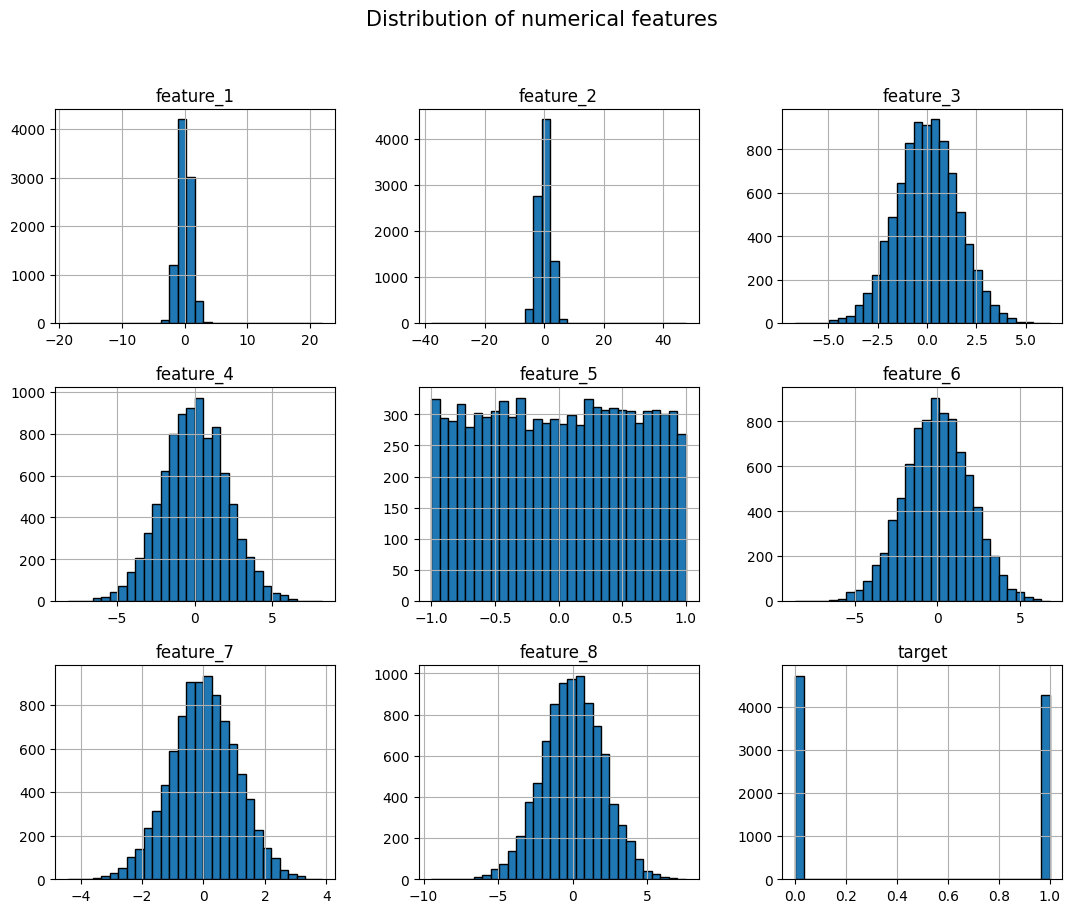

In [ ]:
df.hist(bins = 30, figsize=(13,10), edgecolor = 'black')
plt.suptitle("Distribution of numerical features", fontsize = 15)
plt.show()

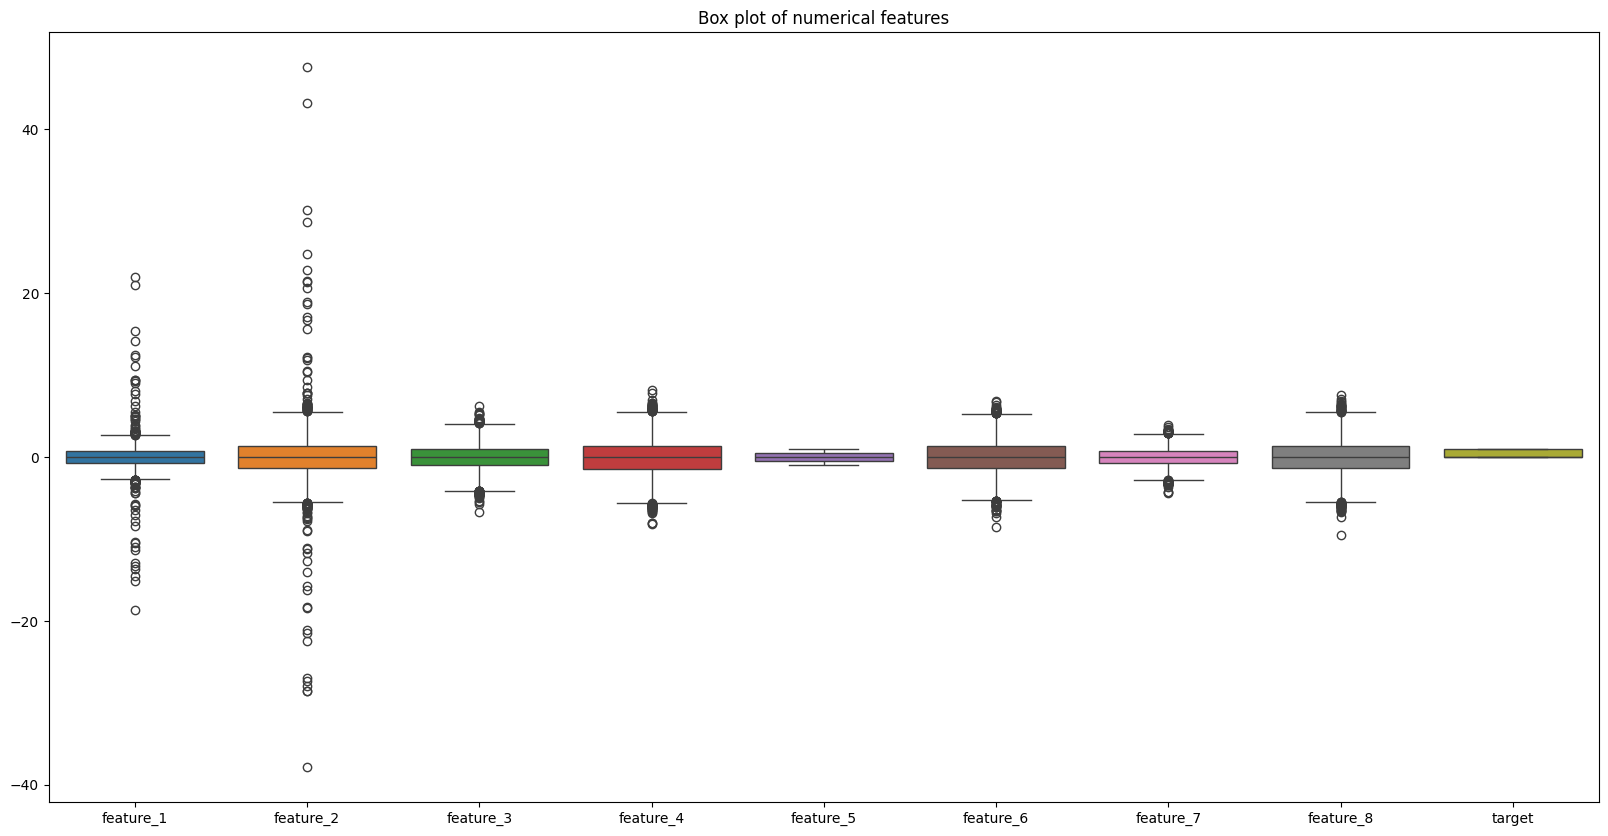

In [ ]:
plt.figure(figsize=(20,10))
sns.boxplot(data=numerical_cols)
plt.title('Box plot of numerical features')
plt.show()

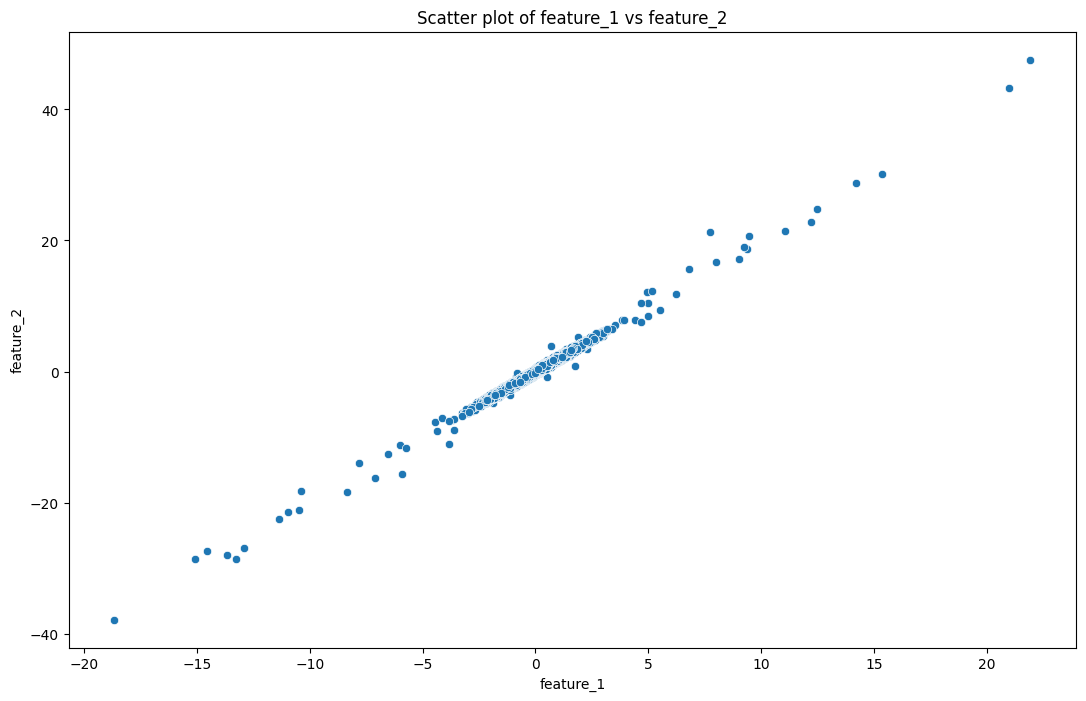

In [ ]:
plt.figure(figsize=(13,8))
sns.scatterplot(x='feature_1', y='feature_2', data=df)
plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.title('Scatter plot of feature_1 vs feature_2')
plt.show()

# II. DATA PREPROCESSING


In [ ]:
df.isna().sum()

,0
feature_1,0
feature_2,0
feature_3,400
feature_4,0
feature_5,0
feature_6,500
feature_7,0
feature_8,0
category_1,0
category_2,0


In [ ]:
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

feature_3    400
feature_6    500
dtype: int64


In [ ]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
df['feature_3'] = imputer.fit_transform(df[['feature_3']])
df['feature_6'] = imputer.fit_transform(df[['feature_6']])

In [ ]:
df['feature_3'].isna().sum()
df['feature_6'].isna().sum()

0

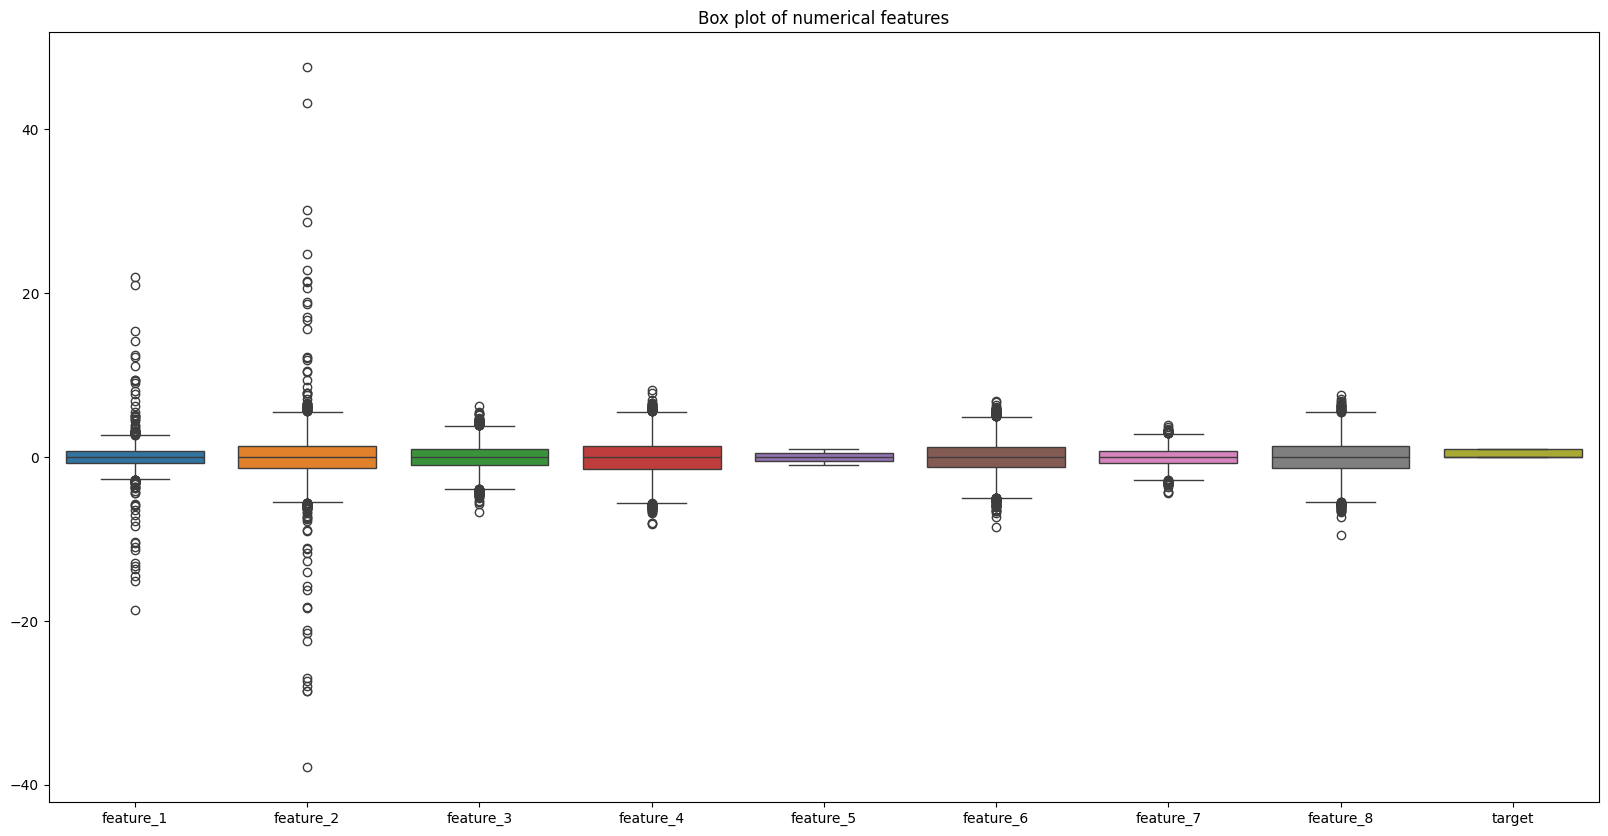

In [ ]:
numerical_features = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(20,10))
plt.title('Box plot of numerical features')
sns.boxplot(data=numerical_features)
plt.show()


In [ ]:
def iqr_outliers(dataset, feature_name, multiplier= 1.5):
    # Calculate IQR
    Q1 = dataset[feature_name].quantile(0.25)
    Q3 = dataset[feature_name].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate limits
    lower_limit = Q1 - multiplier * IQR
    upper_limit = Q3 + multiplier * IQR

    # Identify outliers
    outliers = dataset[(dataset[feature_name] < lower_limit) | (dataset[feature_name] > upper_limit)]

    return outliers, {'lower_limit': lower_limit, 'upper_limit': upper_limit}

outliers_detected = {}

for feature in numerical_features.columns:
    outliers, limits = iqr_outliers(numerical_features, feature)
    outliers_detected[feature] = {
        'count': len(outliers),
        'indices': outliers.index.tolist(),
        'limits': limits
    }

    print(f'Feature: {feature}')
    print(f'Number of outliers: {len(outliers)}')
    print(f'Lower limit: {limits["lower_limit"]}, Upper limit: {limits["upper_limit"]}')
    print(f'Outlier indices: {outliers.index.tolist()}')
    print('-' * 50)

Feature: feature_1
Number of outliers: 113
Lower limit: -2.7209235765, Upper limit: 2.7213741995
Outlier indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1539, 1591, 1615, 1785, 1957, 1971, 2024, 2035, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2521, 2884, 2895, 2947, 3017, 3152, 3227, 3241, 3245, 3336, 3454, 3510, 3569, 3716, 3872, 3982, 3986, 4026, 4029, 4033, 4047, 4091, 4198, 4207, 4265, 4359, 4531, 4617, 4635, 4639, 4725, 4779, 4784, 4870, 4997, 5157, 5224, 5316, 5416, 5488, 5587, 5642, 5649, 5673, 5773, 5796, 5846, 5907, 5935, 5998, 6350, 6408, 6628, 6693, 6738, 6747, 6891, 7060, 7140, 7178, 7223, 7290, 7305, 7330, 7441, 7498, 7611, 7624, 7677, 7839, 7851, 7858, 7872, 7874, 8024, 8067, 8165, 8180, 8200, 8248, 8283, 8354, 8630, 8714, 8726]
--------------------------------------------------
Feature: feature_2
Number of outliers: 106
Lower limit: -5.5268680488749995, Upper limit: 5.524485932125
Outlier indices: [209, 262, 277, 469, 478, 496, 598, 774, 1

In [ ]:
df_stage1 = df.copy()
# Loop through the outliers_detected dictionary and replace the outliers with median values

for feature, values in outliers_detected.items():
    # Get outlier indices
    outlier_indices = values['indices']

    # Calculate the median value for the feature
    median_value = df_stage1[feature].median()

    # Replace the outlier values with the median value
    df_stage1.loc[outlier_indices, feature] = median_value

    # Print out some information for verification
    print(f"Feature: {feature}")
    print(f"Replaced outliers in indices: {outlier_indices}")
    print('-' * 50)

Feature: feature_1
Replaced outliers in indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1539, 1591, 1615, 1785, 1957, 1971, 2024, 2035, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2521, 2884, 2895, 2947, 3017, 3152, 3227, 3241, 3245, 3336, 3454, 3510, 3569, 3716, 3872, 3982, 3986, 4026, 4029, 4033, 4047, 4091, 4198, 4207, 4265, 4359, 4531, 4617, 4635, 4639, 4725, 4779, 4784, 4870, 4997, 5157, 5224, 5316, 5416, 5488, 5587, 5642, 5649, 5673, 5773, 5796, 5846, 5907, 5935, 5998, 6350, 6408, 6628, 6693, 6738, 6747, 6891, 7060, 7140, 7178, 7223, 7290, 7305, 7330, 7441, 7498, 7611, 7624, 7677, 7839, 7851, 7858, 7872, 7874, 8024, 8067, 8165, 8180, 8200, 8248, 8283, 8354, 8630, 8714, 8726]
--------------------------------------------------
Feature: feature_2
Replaced outliers in indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1591, 1615, 1785, 1957, 1971, 2024, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2895, 2947, 3017, 3152, 3227, 3

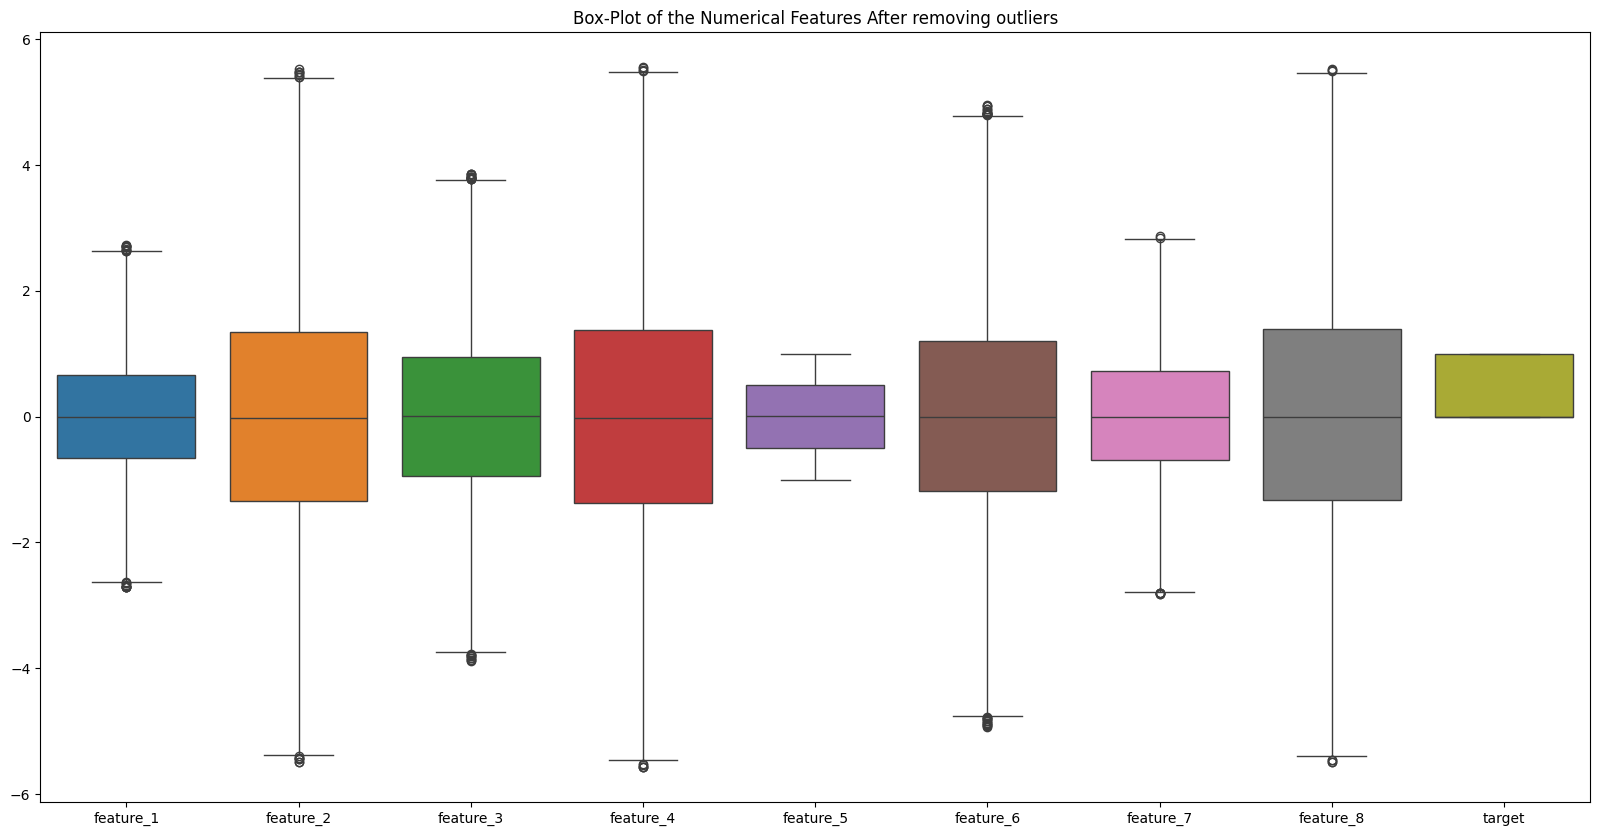

In [ ]:
plt.figure(figsize=(20, 10))
plt.title('Box-Plot of the Numerical Features After removing outliers')
sns.boxplot(data=df_stage1)
plt.show()

In [ ]:
df_stage1.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,-0.000672,0.002354,0.005988,-0.010226,-0.002177,0.004222,0.006010,0.010578,0.475444
std,0.971927,1.959564,1.429225,1.986669,0.577415,1.818435,1.038181,1.980097,0.499424
min,-2.712613,-5.486925,-3.881410,-5.569645,-0.999791,-4.936580,-2.819977,-5.490152,0.000000
25%,-0.657194,-1.346706,-0.939994,-1.377240,-0.502614,-1.186692,-0.684357,-1.329677,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.659561,1.343450,0.941969,1.368650,0.497004,1.202089,0.720851,1.386503,1.000000
max,2.720169,5.516173,3.854354,5.552331,0.999914,4.950231,2.876070,5.529430,1.000000


In [ ]:
category_columns = df_stage1[['category_1', 'category_2']]

for column in category_columns:
    unique_values = df_stage1[column].unique()
    unique_count = df_stage1[column].nunique()

    print(f"Column '{column}':")
    print(f"Unique values: {unique_values}")
    print(f"Number of unique options: {unique_count}")
    print('-' * 30)

Column 'category_1':
Unique values: ['Above Average' 'Below Average' 'High' 'Low']
Number of unique options: 4
------------------------------
Column 'category_2':
Unique values: ['Region C' 'Region A' 'Region B']
Number of unique options: 3
------------------------------


In [ ]:
# Making a copy of the dataset to avoid changing the original data
df_stage2 = df_stage1.copy()
label_encoder = LabelEncoder()
label_encoder = LabelEncoder()
df_stage2['cat_1_encoded'] = label_encoder.fit_transform(df_stage2['category_1'])
# One-Hot Encoding for category_2 (nominal)
df_one_hot = pd.get_dummies(df_stage2['category_2'])

# Combine the original dataframe with the one-hot encoded dataframe
df_stage2 = pd.concat([df_stage2, df_one_hot], axis=1)

# Drop the original category_2 column if no longer needed
df_stage2.drop(columns=['category_1', 'category_2'], inplace=True)

# Display the final dataframe
df_stage2.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,cat_1_encoded,Region A,Region B,Region C
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1,0,False,False,True
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0,1,True,False,False
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1,2,False,False,True
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1,2,False,True,False
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0,1,False,False,True


In [ ]:
print(f'Before changing column names:\n {df_stage2.columns}')

# Renaming columns
df_stage2.rename(columns={
    'Region A': 'region_A',
    'Region B': 'region_B',
    'Region C': 'region_C'
}, inplace=True)

# Verify column names
print(f'After changing column names:\n {df_stage2.columns}')

Before changing column names:
 Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'target', 'cat_1_encoded',
       'Region A', 'Region B', 'Region C'],
      dtype='object')
After changing column names:
 Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'target', 'cat_1_encoded',
       'region_A', 'region_B', 'region_C'],
      dtype='object')


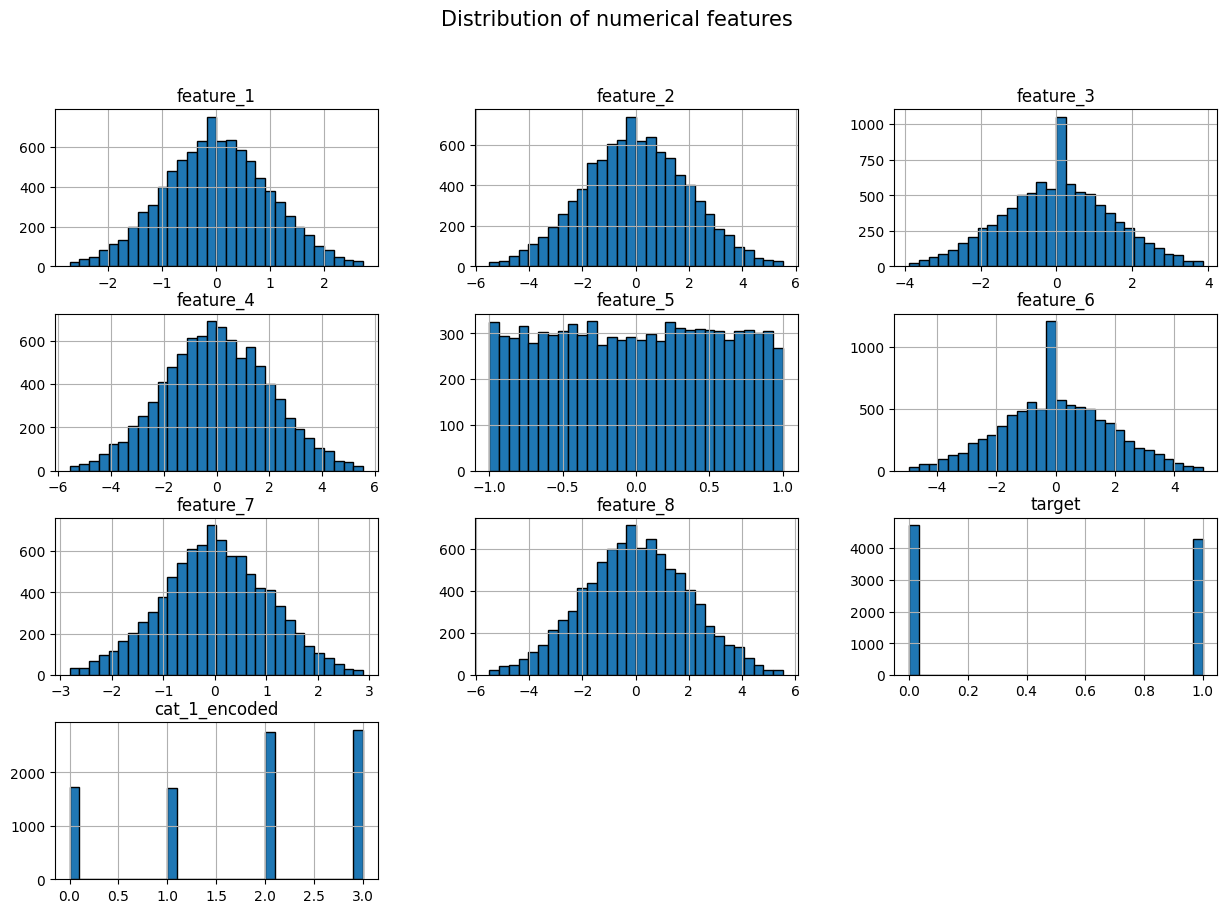

In [ ]:
df_stage2.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.suptitle("Distribution of numerical features", fontsize = 15)
plt.show()

In [ ]:
df_stage2.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,cat_1_encoded
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,-0.000672,0.002354,0.005988,-0.010226,-0.002177,0.004222,0.006010,0.010578,0.475444,1.737778
std,0.971927,1.959564,1.429225,1.986669,0.577415,1.818435,1.038181,1.980097,0.499424,1.095463
min,-2.712613,-5.486925,-3.881410,-5.569645,-0.999791,-4.936580,-2.819977,-5.490152,0.000000,0.000000
25%,-0.657194,-1.346706,-0.939994,-1.377240,-0.502614,-1.186692,-0.684357,-1.329677,0.000000,1.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000,2.000000
75%,0.659561,1.343450,0.941969,1.368650,0.497004,1.202089,0.720851,1.386503,1.000000,3.000000
max,2.720169,5.516173,3.854354,5.552331,0.999914,4.950231,2.876070,5.529430,1.000000,3.000000


In [ ]:
df.to_csv('C:\depression analysis\Machine Learning\final project\cleaned_dataset.csv')

In [ ]:
df_stage3 = df_stage2.copy()

scaler = MinMaxScaler()

# Loop through each numerical feature and apply MinMax scaling
for feature in df_stage3:
    df_stage3[feature] = scaler.fit_transform(df_stage3[[feature]])

# Display the first few rows of the normalized dataset
print(df_stage3.head())

   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   0.590734   0.602870   0.417915   0.575676   0.892487   0.275836   
1   0.473855   0.493050   0.502421   0.537082   0.852358   0.246593   
2   0.618523   0.625464   0.402970   0.654372   0.374936   0.697175   
3   0.779645   0.740199   0.183532   0.738960   0.941135   0.847818   
4   0.456204   0.453284   0.576221   0.461068   0.805315   0.520694   

   feature_7  feature_8  target  cat_1_encoded  region_A  region_B  region_C  
0   0.266829   0.294740     1.0       0.000000       0.0       0.0       1.0  
1   0.259961   0.321959     0.0       0.333333       1.0       0.0       0.0  
2   0.704035   0.634662     1.0       0.666667       0.0       0.0       1.0  
3   0.867424   0.807579     1.0       0.666667       0.0       1.0       0.0  
4   0.659358   0.461786     0.0       0.333333       0.0       0.0       1.0  


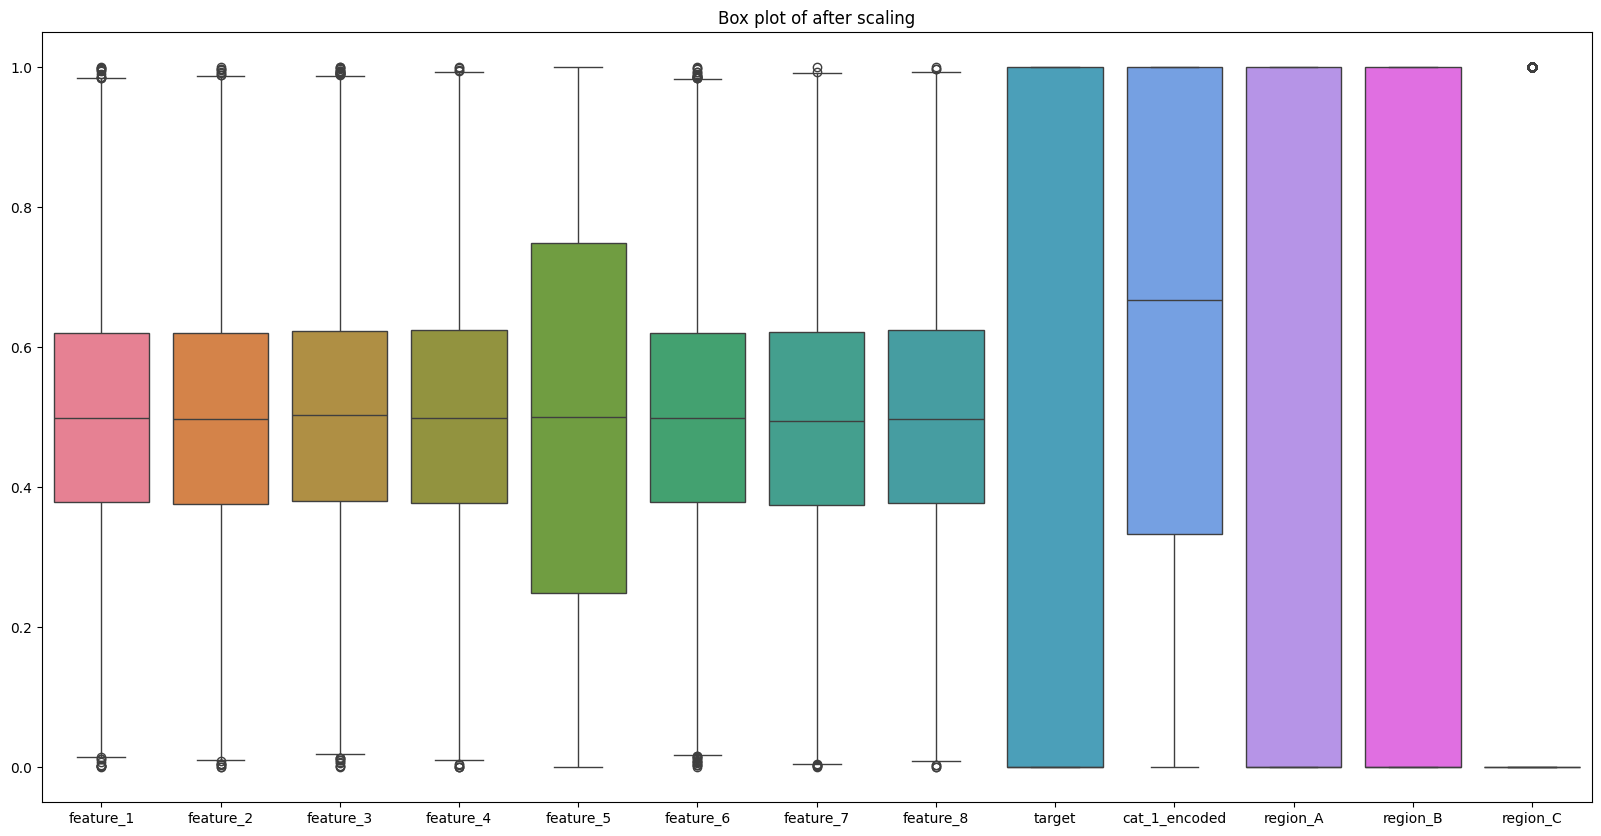

In [ ]:
plt.figure(figsize=(20,10))
plt.title('Box plot of after scaling')
sns.boxplot(data=df_stage3)
plt.show()

# III. EDA (EXPLORATORY DATA ANALYSIS)




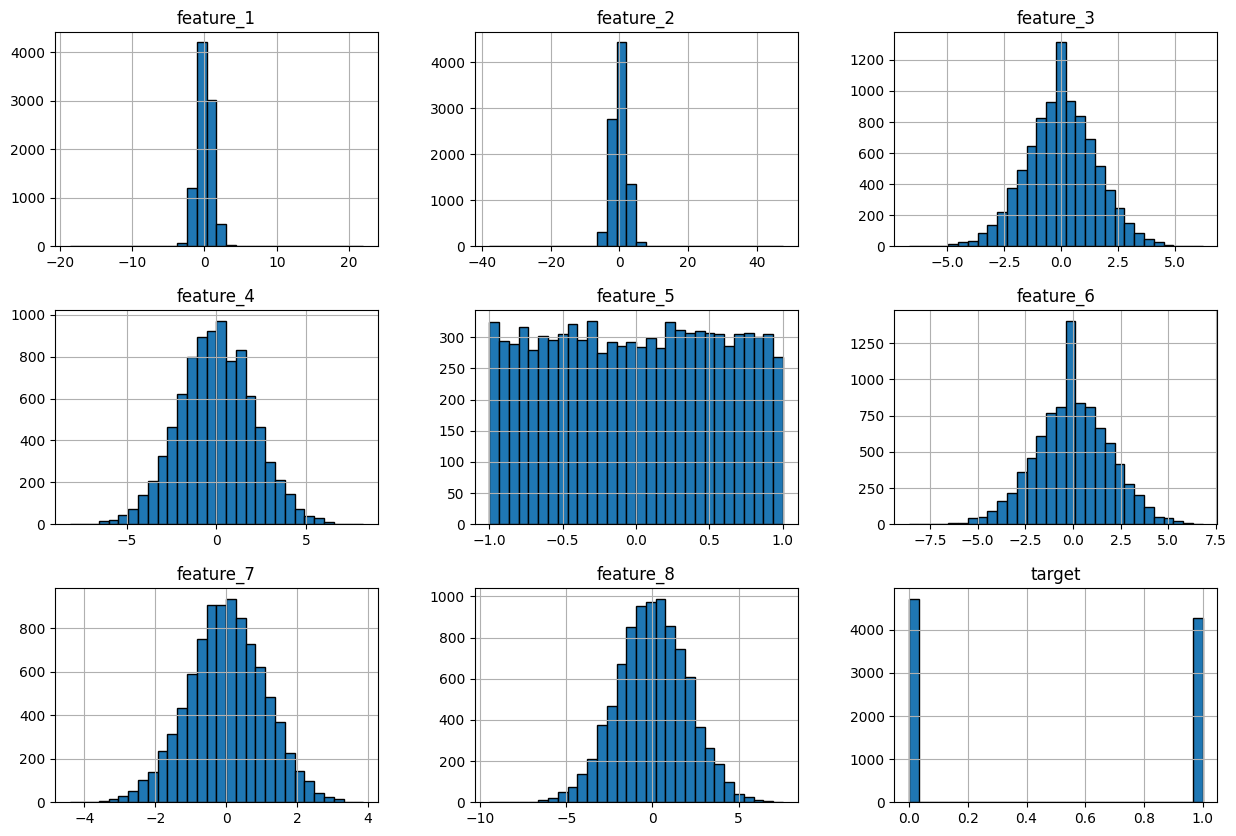

In [ ]:
numerical_features.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.show()

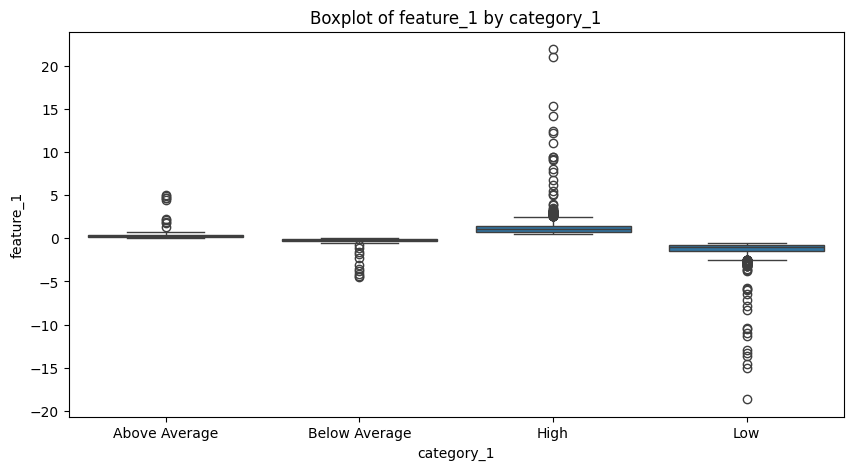

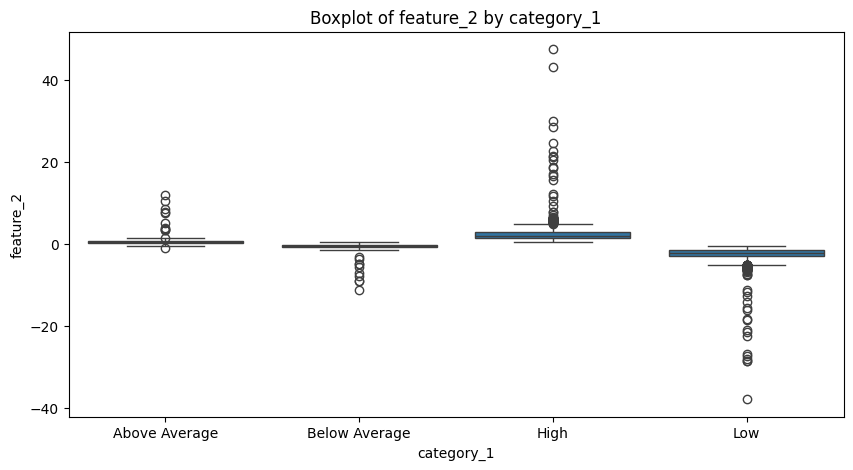

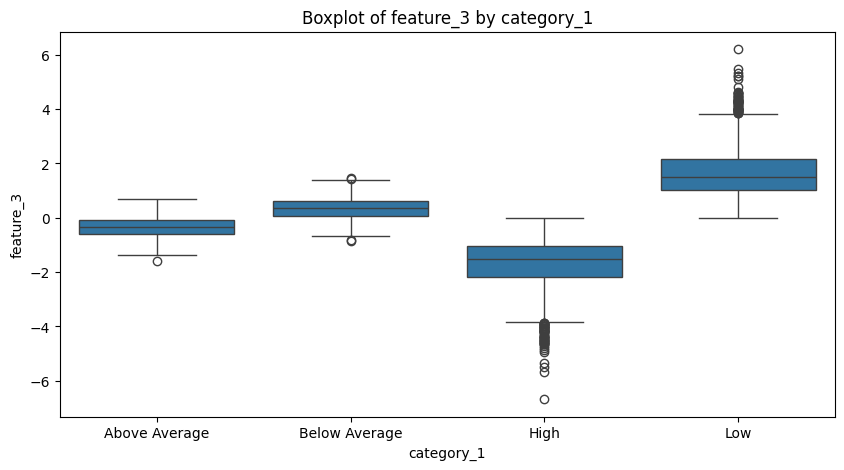

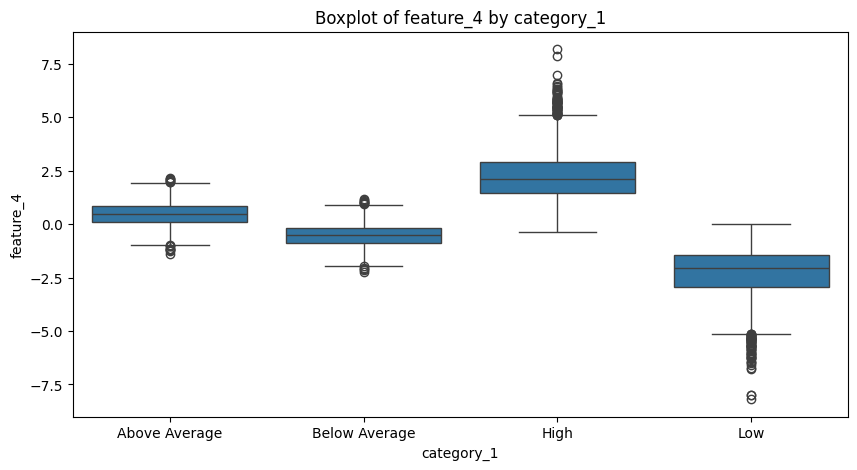

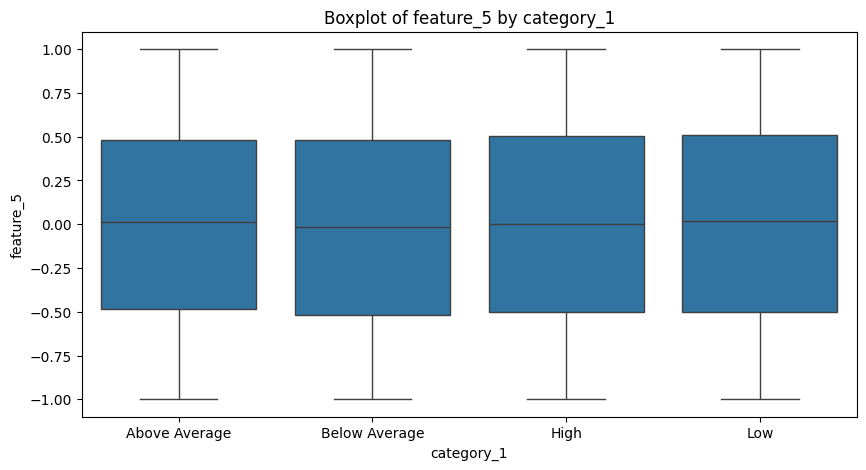

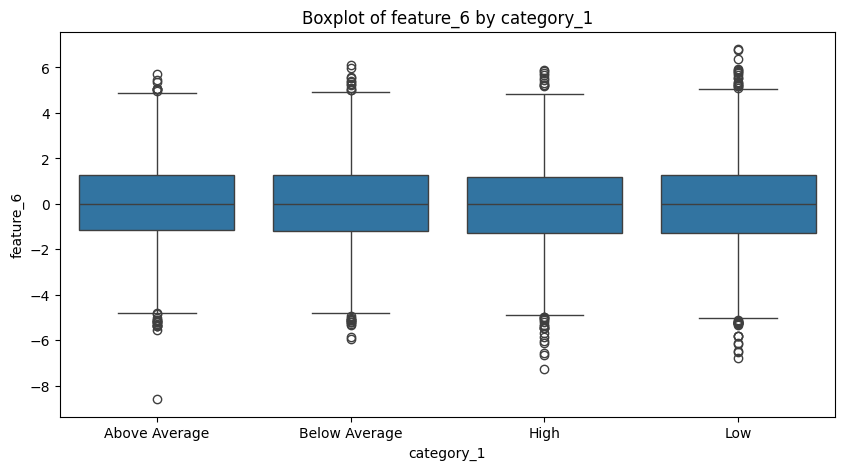

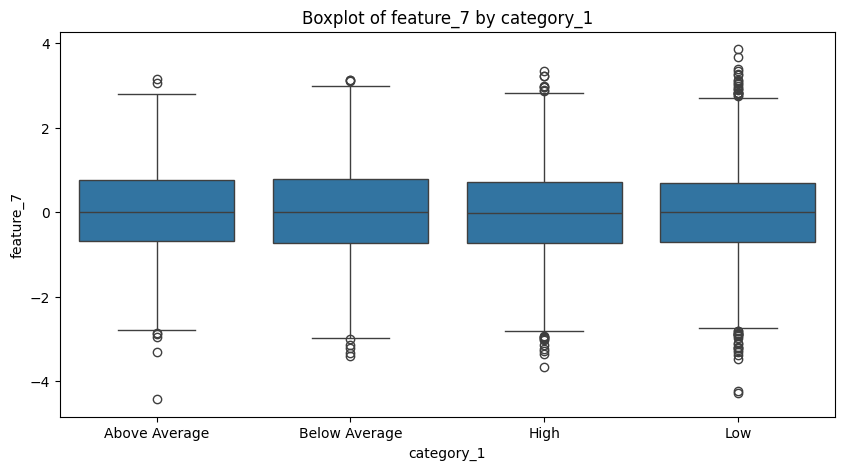

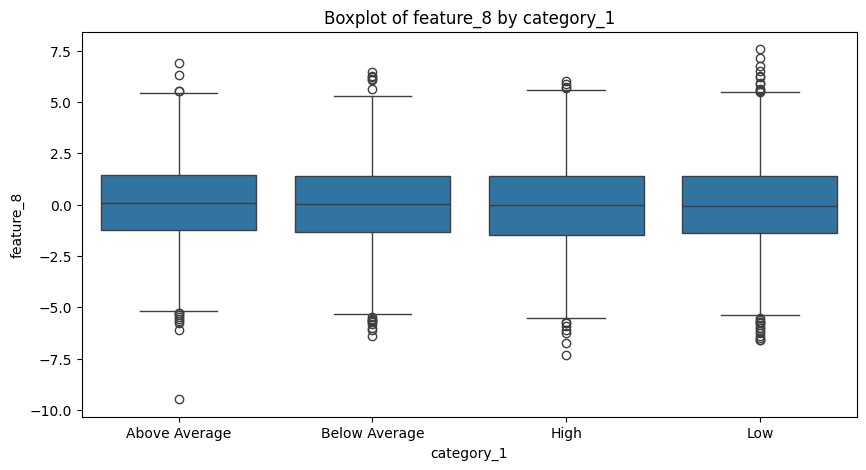

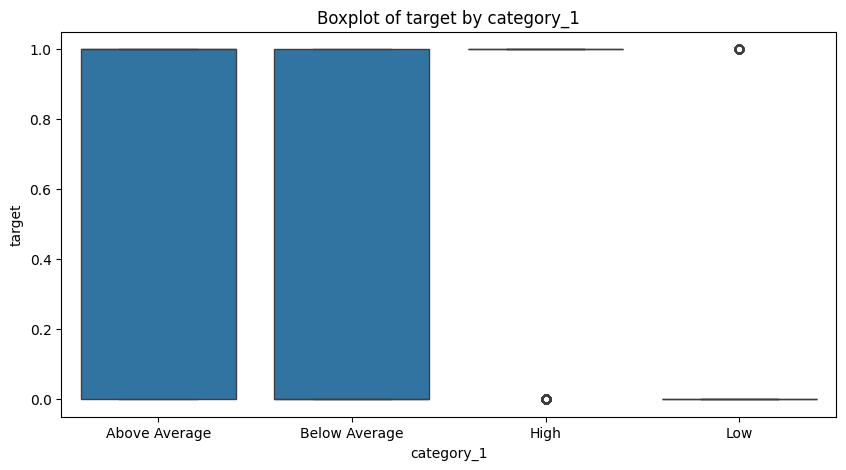

In [ ]:
#relationships between features and the target variable
for column in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='category_1', y=column, data=df)
    #sns.boxplot(x='category_2', y=column, data=df)
    plt.title(f'Boxplot of {column} by category_1')
    plt.show()

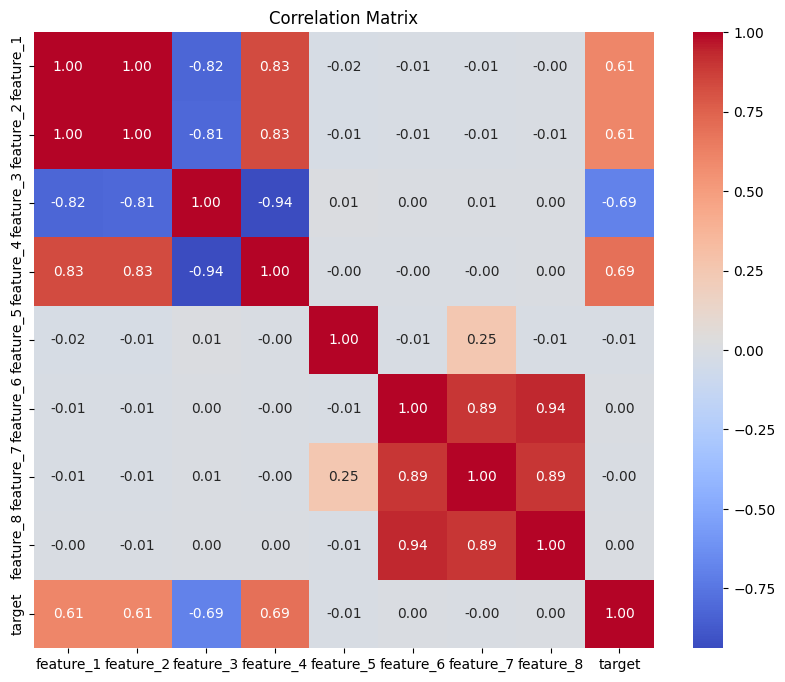

In [ ]:
correlation_matrix = numerical_features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Performing t-tests for each numerical feature against the target variable
results = {}

for feature in numerical_cols[:-1]:  # Exclude the target variable
    group1 = df[df['target'] == 1][feature].dropna()
    group0 = df[df['target'] == 0][feature].dropna()
    t_stat, p_value = stats.ttest_ind(group1, group0)
    results[feature] = {'t_statistic': t_stat, 'p_value': p_value}

# Converting results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df.index.name = 'Feature'

# Displaying the t-test results
print(results_df)

           t_statistic   p_value
Feature                         
feature_1    72.253084  0.000000
feature_2    72.267409  0.000000
feature_3   -90.276861  0.000000
feature_4    91.660903  0.000000
feature_5    -0.746804  0.455201
feature_6     0.134524  0.892991
feature_7    -0.189743  0.849515
feature_8     0.441833  0.658621
target             inf  0.000000


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# Performing chi-square tests for categorical variables against the target variable
chi_square_results = {}

# Chi-square test for category_1
contingency_table_1 = pd.crosstab(df['category_1'], df['target'])
chi2_stat_1, p_value_1, dof_1, expected_1 = stats.chi2_contingency(contingency_table_1)
chi_square_results['category_1'] = {'chi2_statistic': chi2_stat_1, 'p_value': p_value_1}

# Chi-square test for category_2
contingency_table_2 = pd.crosstab(df['category_2'], df['target'])
chi2_stat_2, p_value_2, dof_2, expected_2 = stats.chi2_contingency(contingency_table_2)
chi_square_results['category_2'] = {'chi2_statistic': chi2_stat_2, 'p_value': p_value_2}

# Converting results to a DataFrame for better visualization
chi_square_results_df = pd.DataFrame.from_dict(chi_square_results, orient='index')
chi_square_results_df.index.name = 'Category'

# Displaying the chi-square test results
print(chi_square_results_df)

            chi2_statistic  p_value
Category                           
category_1     5175.320287  0.00000
category_2        1.319349  0.51702


# IV. FEATURE ENGINEERING

In [43]:
df_stage4 = df_stage3.copy()
# Function to engineer new features
def feature_engineering(df_stage4):
    # Create new features based on existing ones
    df_stage4['feature_9'] = df_stage4['feature_1'] / (df_stage4['feature_2'] + 1)
    df_stage4['feature_10'] = df_stage4['feature_3'] / (df_stage4['feature_4'] + 1)
    return df_stage4

# Apply feature engineering
df_stage4 = feature_engineering(df_stage4)

# Creating polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

# Selecting relevant features for polynomial transformation
features_to_transform = df_stage4[['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_9', 'feature_10']]

# Transforming the features
poly_features = poly.fit_transform(features_to_transform)

# Creating a DataFrame for the new polynomial features
poly_features_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(features_to_transform.columns))

# Concatenating the polynomial features with the original DataFrame
df_stage4 = pd.concat([df_stage4.reset_index(drop=True), poly_features_df.reset_index(drop=True)], axis=1)

df_stage4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 42 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   feature_1             9000 non-null   float64
 1   feature_2             9000 non-null   float64
 2   feature_3             9000 non-null   float64
 3   feature_4             9000 non-null   float64
 4   feature_5             9000 non-null   float64
 5   feature_6             9000 non-null   float64
 6   feature_7             9000 non-null   float64
 7   feature_8             9000 non-null   float64
 8   target                9000 non-null   float64
 9   cat_1_encoded         9000 non-null   float64
 10  region_A              9000 non-null   float64
 11  region_B              9000 non-null   float64
 12  region_C              9000 non-null   float64
 13  feature_9             9000 non-null   float64
 14  feature_10            9000 non-null   float64
 15  feature_1            